# Quantum Kernel Classification Project

#### Mohamed Abdelazeem Ahmedy. Code: 2300310 

## Project objectives
- Implement quantum feature maps and compute quantum kernels.
- Understand the theoretical basis of quantum-enhanced feature spaces.
- Build and train SVM classifiers with precomputed quantum kernels.
- Compare quantum and classical models.
- Extend the study with PCA and angle embedding.

## Part 1

### 1.1 What is a quantum feature map?

A feature map is the transformation that converts raw input data into a representation that a learning algorithm can use effectively.

In quantum kernel methods, a classical vector $x \in \mathbb{R}^d$ is encoded into a quantum state using a parameterized circuit:

$$
x \mapsto |\phi(x)\rangle = U_{\phi}(x) |0\rangle^{\otimes n}.
$$

Here, $U_{\phi}(x)$ is called the quantum feature map. Its gate angles depend on the input features. Local rotations inject individual features, and entangling gates can inject interaction terms such as $x_i x_j$.

- before encoding, two samples are just points in classical space,
- after encoding, those samples become quantum states,
- the geometry of those quantum states is what the kernel method uses.

### 1.2 Core idea of the quantum kernel

Once each input is encoded as a quantum state, similarity is measured by state overlap.

The quantum kernel between two inputs $x$ and $x'$ is

$$
K(x, x') = |\langle \phi(x) | \phi(x') \rangle|^2.
$$

Intuition:
- large overlap near 1 means the two inputs are represented similarly,
- small overlap near 0 means they are represented differently.

This is analogous to classical kernels, where similarity is measured through inner products in a transformed feature space:

$$
k(x, x') = \langle \phi(x), \phi(x') \rangle.
$$

### 1.3 How a quantum kernel matrix is constructed

Given a dataset $\{x_1, x_2, \ldots, x_m\}$:

1. Encode each sample using the feature map to get states $|\phi(x_i)\rangle$.
2. Compute pairwise similarities using squared overlaps.
3. Store them in the kernel matrix

$$
K_{ij} = |\langle \phi(x_i) | \phi(x_j) \rangle|^2, \quad K \in \mathbb{R}^{m \times m}.
$$

An equivalent circuit expression is

$$
K(x_i, x_j) = |\langle 0^n | U_{\phi}(x_j)^{\dagger} U_{\phi}(x_i) | 0^n \rangle|^2.
$$

In ideal simulation, this matrix should be:
- symmetric: $K_{ij} = K_{ji}$,
- positive semidefinite: all eigenvalues are non-negative,
- with diagonal values close to 1: $K_{ii} \approx 1$.

## Part 2: Implementing Quantum Feature Maps

The notebook uses two original features from the Breast Cancer Wisconsin dataset: `mean radius` and `mean texture`. Those raw features are scaled into the interval $[0, \pi]$ so they can be used directly as rotation angles.

What to build in this part:
- a small binary dataset from scikit-learn,
- a basic feature map built from local rotations,
- a more expressive entangled feature map with a two-qubit interaction,
- circuit visualizations for a few real samples,
- a short discussion of what extra structure the entangled map introduces.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#### Loading the dataset..

In [2]:
data = load_breast_cancer(as_frame=True)
#print(data)

print("Target names:", data.target_names)
print("feature count:", len(data.feature_names))
print("Feature names:", data.feature_names)


Target names: ['malignant' 'benign']
feature count: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


#### Inspect the first 10 samples with features and label:

In [3]:
selected_features = ["mean radius", "mean texture"]
class_names = data.target_names

X_raw = data.frame[selected_features].copy()
y = data.target.to_numpy()

sample_table = X_raw.head(10).copy()
sample_table["label"] = [class_names[label] for label in y[:10]]

print("First 10 samples with features and label:")
display(sample_table)

First 10 samples with features and label:


,mean radius,mean texture,label
0,17.99,10.38,malignant
1,20.57,17.77,malignant
2,19.69,21.25,malignant
3,11.42,20.38,malignant
4,20.29,14.34,malignant
5,12.45,15.70,malignant
6,18.25,19.98,malignant
7,13.71,20.83,malignant
8,13.00,21.82,malignant
9,12.46,24.04,malignant


#### Split the selected features into training and test sets before scaling.

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

print("Dataset sizes after splitting:")
print("X_train_raw samples:", len(X_train_raw))
print("X_test_raw samples:", len(X_test_raw))
print("y_train labels:", len(y_train))
print("y_test labels:", len(y_test))

Dataset sizes after splitting:
X_train_raw samples: 426
X_test_raw samples: 143
y_train labels: 426
y_test labels: 143


#### Scale training and test features to [0, pi] using a scaler fit on training data only.

In [5]:
scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# print("Type of X_train:", type(X_train))
# print("Type of X_test:", type(X_test))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("First 5 scaled training rows:")
print(np.round(X_train[:5], 3))
print("Scaled training range:", round(float(X_train.min()), 4), "to", round(float(X_train.max()), 4))
print("Scaled test range:", round(float(X_test.min()), 4), "to", round(float(X_test.max()), 4))

X_train shape: (426, 2)
X_test shape: (143, 2)
First 5 scaled training rows:
[[1.919 1.121]
 [0.879 0.362]
 [1.511 0.711]
 [1.534 0.783]
 [2.235 1.295]]
Scaled training range: 0.0 to 3.1416
Scaled test range: 0.1158 to 3.039


#### Preview the scaled training samples and their labels.

In [6]:
malignant_index = int(np.flatnonzero(y_train == 0)[0])
benign_index = int(np.flatnonzero(y_train == 1)[0])
reference_index = min(10, len(X_train) - 1)

sample_specs = [
    ("Malignant sample", malignant_index),
    ("Benign sample", benign_index),
    ("Reference sample", reference_index),
]

for name, idx in sample_specs:
    print(f"{name}:")
    print("  index =", idx)
    print("  label =", y_train[idx])
    print("  scaled features =", np.round(X_train[idx], 3))

Malignant sample:
  index = 0
  label = 0
  scaled features = [1.919 1.121]
Benign sample:
  index = 1
  label = 1
  scaled features = [0.879 0.362]
Reference sample:
  index = 10
  label = 1
  scaled features = [1.198 0.747]


#### Visualize the `mean radius` and `mean texture` features before scaling.

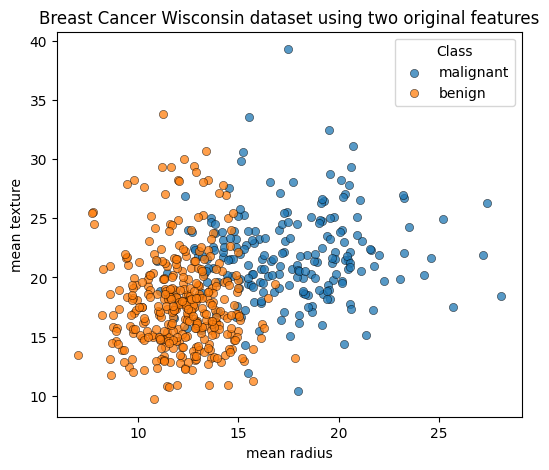

In [9]:
plt.figure(figsize=(6, 5))
for class_index, class_name in enumerate(class_names):
    class_mask = y == class_index
    plt.scatter(
        X_raw.iloc[class_mask, 0],
        X_raw.iloc[class_mask, 1],
        label=class_name,
        edgecolor="black",
        alpha=0.75,
        s=35,
        linewidth=0.4,
    )

plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title("Breast Cancer Wisconsin dataset using two original features")
plt.legend(title="Class")
plt.show()

#### Visualize the `mean radius` and `mean texture` features after scaling.

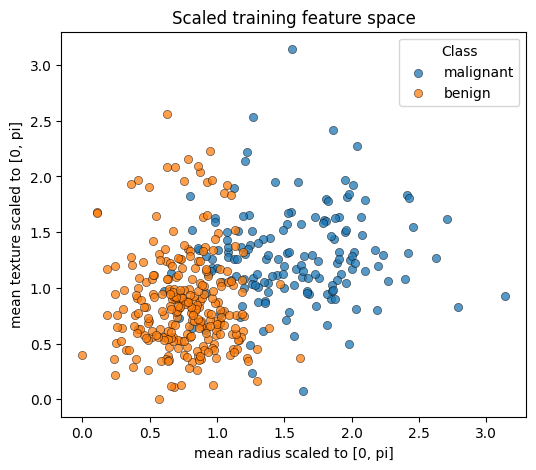

In [10]:
plt.figure(figsize=(6, 5))
for class_index, class_name in enumerate(class_names):
    class_mask = y_train == class_index
    plt.scatter(
        X_train[class_mask, 0],
        X_train[class_mask, 1],
        label=class_name,
        edgecolor="black",
        alpha=0.75,
        s=35,
        linewidth=0.4,
    )

plt.xlabel(f"{selected_features[0]} scaled to [0, pi]")
plt.ylabel(f"{selected_features[1]} scaled to [0, pi]")
plt.title("Scaled training feature space")
plt.legend(title="Class")
plt.show()

### 2.1 Basic feature map: local RX and RZ rotations

RX and RZ gates are used to encode the two features into the quantum state. Each feature is encoded on a separate qubit using local rotations.

Intuition:
- `RX` changes amplitudes based on the feature value.
- `RZ` adds a feature-dependent phase on the same qubit.

In [11]:
num_wires = 2
wires = list(range(num_wires))
dev = qml.device("default.qubit", wires=num_wires)

def basic_feature_map(x):
    for wire, angle in enumerate(x):
        qml.RX(angle, wires=wire)
        qml.RZ(angle, wires=wire)

@qml.qnode(dev)
def basic_feature_map_circuit(x):
    basic_feature_map(x)
    return qml.probs(wires=wires)

### 2.2 Visualize the RX/RZ feature map

This cell draws only the basic RX/RZ feature map for 3 training samples

Malignant sample (malignant) -> scaled features [1.919 1.121]


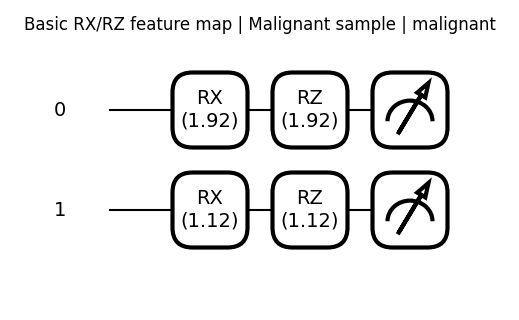

Benign sample (benign) -> scaled features [0.879 0.362]


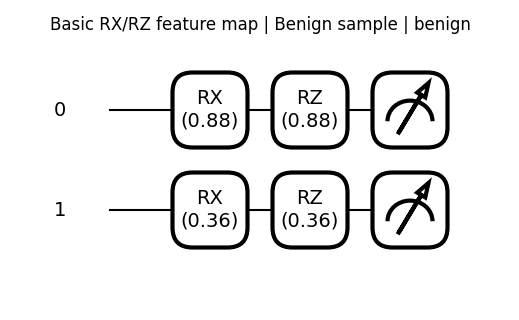

Reference sample (benign) -> scaled features [1.198 0.747]


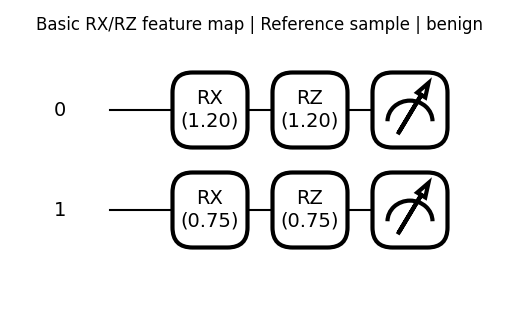

In [12]:
for sample_name, sample_index in sample_specs:
    sample = X_train[sample_index]
    sample_label = class_names[y_train[sample_index]]
    print(f"{sample_name} ({sample_label}) -> scaled features {np.round(sample, 3)}")

    fig_basic, _ = qml.draw_mpl(basic_feature_map_circuit, decimals=2)(sample)
    fig_basic.suptitle(f"Basic RX/RZ feature map | {sample_name} | {sample_label}")
    plt.show()

### 2.3 ZZ-style entangled feature map

The ZZ feature map adds an `IsingZZ` gate after the local rotations. This creates an interaction between the two qubits that depends on the product of the two features. This allows the quantum state to capture correlations between features, which can increase expressivity.

Initution:
- the local rotations still inject the original features into each qubit,
- the `IsingZZ` gate adds an interaction proportional to $x_1 x_2$,


In [13]:
def entangled_feature_map(x):
    for wire, angle in enumerate(x):
        qml.Hadamard(wires=wire)
        qml.RZ(angle, wires=wire)
        qml.RX(angle / 2, wires=wire)
    qml.IsingZZ(x[0] * x[1], wires=[0, 1])

@qml.qnode(dev)
def entangled_feature_map_circuit(x):
    entangled_feature_map(x)
    return qml.probs(wires=wires)

### 2.4 Visualize the ZZ-style feature map

This cell draws only the entangled ZZ-style feature map for the same real training samples. Keeping it separate from the basic map makes it easier to compare how the extra interaction changes the circuit structure.

In the Qiskit view below, the ZZ interaction is shown with its standard two-CNOT decomposition, $\mathrm{CX} \rightarrow R_Z(\theta) \rightarrow \mathrm{CX}$, where $\theta = x_1 x_2$. This makes the ZZ coupling easier to see gate by gate.

Malignant sample (malignant) -> scaled features [1.919 1.121]


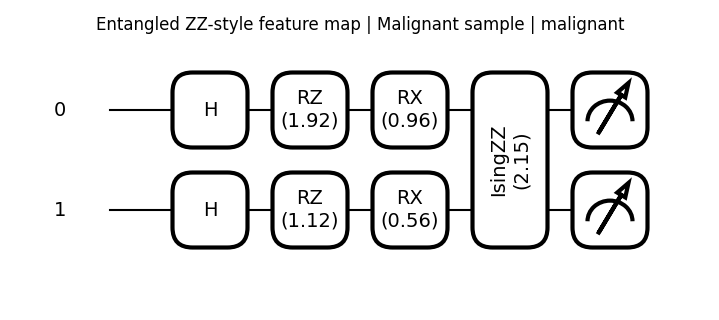

Benign sample (benign) -> scaled features [0.879 0.362]


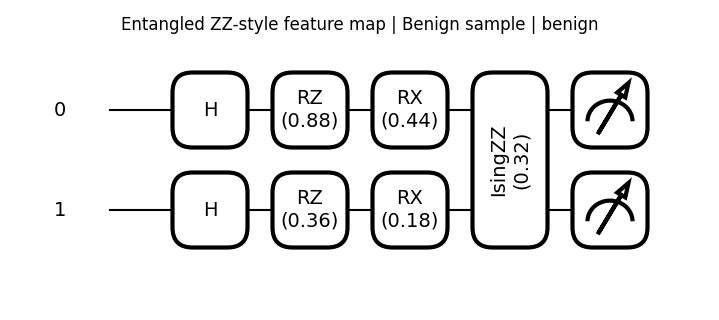

Reference sample (benign) -> scaled features [1.198 0.747]


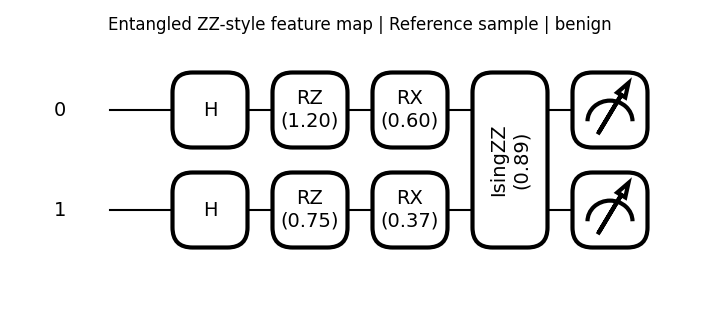

In [14]:
for sample_name, sample_index in sample_specs:
    sample = X_train[sample_index]
    sample_label = class_names[y_train[sample_index]]
    print(f"{sample_name} ({sample_label}) -> scaled features {np.round(sample, 3)}")

    fig_entangled, _ = qml.draw_mpl(entangled_feature_map_circuit, decimals=2)(sample)
    fig_entangled.suptitle(f"Entangled ZZ-style feature map | {sample_name} | {sample_label}")
    plt.show()

Malignant sample (malignant) -> scaled features [1.919 1.121]


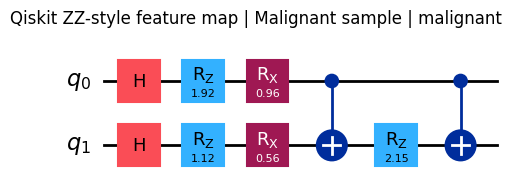

Benign sample (benign) -> scaled features [0.879 0.362]


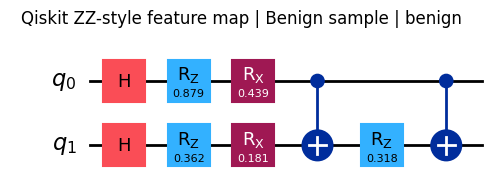

Reference sample (benign) -> scaled features [1.198 0.747]


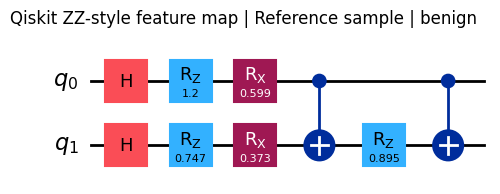

In [11]:
try:
    from io import BytesIO
    from qiskit import QuantumCircuit
    from IPython.display import Image, display
except ImportError as exc:
    raise ImportError(
        "Qiskit is required for this cell. Install qiskit in the active notebook environment to draw the circuit."
    ) from exc

for sample_name, sample_index in sample_specs:
    sample = X_train[sample_index]
    sample_label = class_names[y_train[sample_index]]
    print(f"{sample_name} ({sample_label}) -> scaled features {np.round(sample, 3)}")

    qiskit_circuit = QuantumCircuit(2, name="ZZ-style feature map")
    for wire, angle in enumerate(sample):
        qiskit_circuit.h(wire)
        qiskit_circuit.rz(float(angle), wire)
        qiskit_circuit.rx(float(angle / 2.0), wire)
    zz_angle = float(sample[0] * sample[1])
    qiskit_circuit.cx(0, 1)
    qiskit_circuit.rz(zz_angle, 1)
    qiskit_circuit.cx(0, 1)

    fig = qiskit_circuit.draw(output="mpl")
    fig.suptitle(f"Qiskit ZZ-style feature map | {sample_name} | {sample_label}")

    buffer = BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

### 2.5 Design comparison

The basic map is shallow, easy to interpret, and injects each feature independently. If a later kernel built from this map performs poorly, that tells us the problem may require richer feature interactions than single-qubit rotations can provide.

The entangled map adds a ZZ-style interaction through `IsingZZ(x_1 x_2)`. That interaction makes the encoded state sensitive to joint structure between `mean radius` and `mean texture`. In practical terms, this increases expressivity because the similarity between two inputs now depends not only on separate coordinate differences but also on how their feature pair behaves together.

## Part 3: Quantum Kernel Computation

This part uses the two feature maps from Part 2 to compute quantum kernel matrices on the dataset. For each map, the notebook simulates pairwise state overlaps for the first 15 training entries, visualizes the resulting kernel matrix as a heatmap, and checks whether the matrix satisfies the basic kernel properties expected in the noiseless setting.

### how the kernel matrix is computed?

For each input sample $x$, the feature map circuit prepares a quantum state $|\phi(x)\rangle$. The code first builds these states for the selected samples.

Then, for every pair of samples $x_i$ and $x_j$, it computes their overlap

$$
\langle \phi(x_i) | \phi(x_j) \rangle
$$

and stores the squared magnitude

$$
K(x_i, x_j) = \left|\langle \phi(x_i) | \phi(x_j) \rangle\right|^2.
$$

This means:
- if two encoded states are very similar, the kernel value is close to 1,
- if they are less similar, the kernel value is smaller.

So the code matches the quantum kernel definition directly. It computes the inner product between simulated quantum states and uses its squared magnitude as the kernel entry.

#### Helper functions to compute and analyze quantum kernel matrices

- `basic_feature_map_state(x)`: prepares the RX/RZ-encoded quantum state and returns the statevector.
- `entangled_feature_map_state(x)`: prepares the ZZ-style encoded quantum state and returns the statevector.
- `compute_quantum_kernel_matrix(state_fn, samples_a, samples_b=None)`: builds a kernel matrix from pairwise squared overlaps between encoded states.
- `format_kernel_table(kernel_matrix, labels)`: converts a kernel matrix into a readable labeled DataFrame.
- `plot_kernel_matrix(kernel_matrix, labels, title)`: visualizes the kernel matrix as a heatmap with class-aware axis labels.
- `summarize_kernel_structure(kernel_matrix, labels)`: computes average within-class and between-class similarities.
- `validate_kernel_matrix(kernel_matrix)`: reports symmetry error, diagonal error, and minimum eigenvalue for kernel validity checks.

In [15]:
kernel_subset_size = 15
X_kernel = X_train[:kernel_subset_size]
y_kernel = y_train[:kernel_subset_size]

@qml.qnode(dev)
def basic_feature_map_state(x):
    basic_feature_map(x)
    return qml.state()

@qml.qnode(dev)
def entangled_feature_map_state(x):
    entangled_feature_map(x)
    return qml.state()

def compute_quantum_kernel_matrix(state_fn, samples_a, samples_b=None):
    if samples_b is None:
        samples_b = samples_a

    # Precompute states for all samples to avoid redundant circuit executions
    states_a = [state_fn(sample) for sample in samples_a]
    states_b = states_a if samples_b is samples_a else [state_fn(sample) for sample in samples_b]
    kernel_matrix = np.zeros((len(samples_a), len(samples_b)))
    # Compute pairwise overlaps to fill the kernel matrix
    for row, state_a in enumerate(states_a):
        for col, state_b in enumerate(states_b):
            overlap = np.vdot(state_a, state_b)
            kernel_matrix[row, col] = np.abs(overlap) ** 2

    return kernel_matrix

def format_kernel_table(kernel_matrix, labels):
    axis_labels = [f"S{idx}_{class_names[label][0].upper()}" for idx, label in enumerate(labels)]
    return pd.DataFrame(
        np.round(kernel_matrix, 4),
        index=axis_labels,
        columns=axis_labels,
    )

def plot_kernel_matrix(kernel_matrix, labels, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(kernel_matrix, cmap="viridis", interpolation="nearest")
    plt.colorbar(label="Kernel value")
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Sample index")
    tick_positions = np.arange(len(labels))
    tick_labels = [f"{idx}\n{class_names[label][0].upper()}" for idx, label in enumerate(labels)]
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.yticks(tick_positions, tick_labels)
    plt.tight_layout()
    plt.show()

def summarize_kernel_structure(kernel_matrix, labels):
    same_class_mask = labels[:, None] == labels[None, :]
    off_diagonal_mask = ~np.eye(len(labels), dtype=bool)
    within_class = kernel_matrix[same_class_mask & off_diagonal_mask]
    between_class = kernel_matrix[~same_class_mask]
    return within_class.mean(), between_class.mean()

def validate_kernel_matrix(kernel_matrix):
    symmetric_error = np.max(np.abs(kernel_matrix - kernel_matrix.T))
    diagonal_error = np.max(np.abs(np.diag(kernel_matrix) - 1.0))
    min_eigenvalue = np.min(np.linalg.eigvalsh(kernel_matrix))
    return symmetric_error, diagonal_error, min_eigenvalue

In [66]:
selected_kernel_samples = pd.DataFrame(
    np.round(X_kernel, 4),
    columns=[f"{feature} (scaled)" for feature in selected_features],
    index=[f"S{idx}_{class_names[label][0].upper()}" for idx, label in enumerate(y_kernel)],
)
selected_kernel_samples.index.name = "kernel_id"
selected_kernel_samples.insert(
    0,
    "class_label",
    [class_names[label] for label in y_kernel],
)

print("Selected samples used in the kernel matrix:")
display(selected_kernel_samples)

Selected samples used in the kernel matrix:


,class_label,mean radius (scaled),mean texture (scaled)
kernel_id,,,
S0_M,malignant,1.9194,1.1209
S1_B,benign,0.8786,0.3623
S2_M,malignant,1.5105,0.7108
S3_M,malignant,1.5343,0.7830
S4_M,malignant,2.2346,1.2951
S5_M,malignant,1.4436,1.1145
S6_B,benign,0.7314,0.5248
S7_M,malignant,1.6369,0.0712
S8_M,malignant,1.5194,1.5735


### 3.1 Kernel matrix for the RX/RZ feature map

This cell computes the quantum kernel matrix for the first 15 training samples using the separable RX/RZ feature map. The heatmap uses the first letter of the class name on each axis, so `M` marks malignant and `B` marks benign.

Basic RX/RZ kernel matrix:


,S0_M,S1_B,S2_M,S3_M,S4_M,S5_M,S6_B,S7_M,S8_M,S9_B,S10_B,S11_M,S12_M,S13_M,S14_B
S0_M,1.0000,0.4701,0.8596,0.8860,0.9436,0.8927,0.4288,0.7047,0.8351,0.3470,0.7239,0.6259,0.7332,0.6453,0.6051
S1_B,0.4701,1.0000,0.7986,0.7720,0.2682,0.7095,0.9841,0.7414,0.4627,0.8438,0.9132,0.7875,0.8936,0.5990,0.8248
S2_M,0.8596,0.7986,1.0000,0.9978,0.6711,0.9342,0.7509,0.8895,0.7111,0.6081,0.9529,0.7931,0.9440,0.6899,0.8005
S3_M,0.8860,0.7720,0.9978,1.0000,0.7047,0.9516,0.7287,0.8679,0.7471,0.5983,0.9455,0.8018,0.9408,0.7134,0.8051
S4_M,0.9436,0.2682,0.6711,0.7047,1.0000,0.7244,0.2281,0.5472,0.7516,0.1658,0.5051,0.4188,0.5153,0.4800,0.3927
S5_M,0.8927,0.7095,0.9342,0.9516,0.7244,1.0000,0.7003,0.7222,0.8992,0.6459,0.9190,0.8967,0.9368,0.8717,0.8844
S6_B,0.4288,0.9841,0.7509,0.7287,0.2281,0.7003,1.0000,0.6454,0.4705,0.9192,0.8982,0.8303,0.8881,0.6415,0.8673
S7_M,0.7047,0.7414,0.8895,0.8679,0.5472,0.7222,0.6454,1.0000,0.4977,0.4432,0.8040,0.5656,0.7713,0.4624,0.5801
S8_M,0.8351,0.4627,0.7111,0.7471,0.7516,0.8992,0.4705,0.4977,1.0000,0.4934,0.6931,0.8008,0.7320,0.9050,0.7625
S9_B,0.3470,0.8438,0.6081,0.5983,0.1658,0.6459,0.9192,0.4432,0.4934,1.0000,0.7893,0.8696,0.8020,0.7257,0.8959


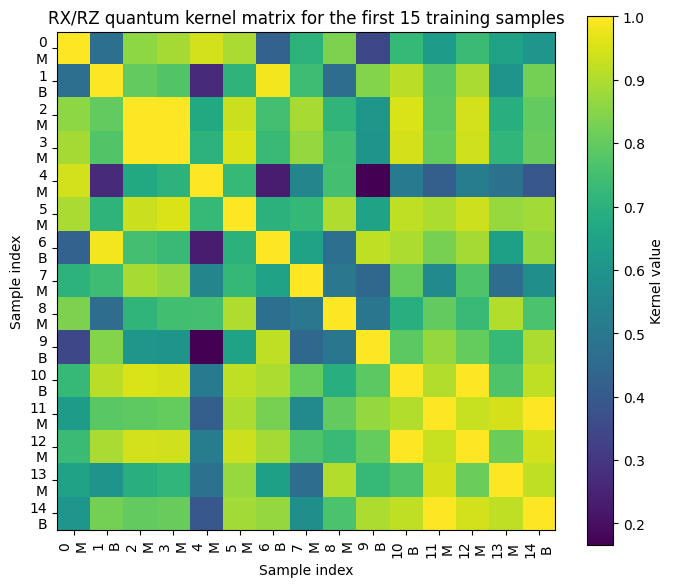

Basic RX/RZ kernel summary:
  shape = (15, 15)
  average within-class off-diagonal similarity = 0.7914
  average between-class similarity = 0.6883
  comment: because this map is separable, it usually creates smoother similarity patterns and weaker feature interaction structure.


In [16]:
basic_kernel_matrix = compute_quantum_kernel_matrix(basic_feature_map_state, X_kernel)
basic_within_class_mean, basic_between_class_mean = summarize_kernel_structure(
    basic_kernel_matrix, y_kernel
)

print("Basic RX/RZ kernel matrix:")
display(format_kernel_table(basic_kernel_matrix, y_kernel))

plot_kernel_matrix(
    basic_kernel_matrix,
    y_kernel,
    "RX/RZ quantum kernel matrix for the first 15 training samples",
)

print("Basic RX/RZ kernel summary:")
print("  shape =", basic_kernel_matrix.shape)
print("  average within-class off-diagonal similarity =", round(float(basic_within_class_mean), 4))
print("  average between-class similarity =", round(float(basic_between_class_mean), 4))
print("  comment: because this map is separable, it usually creates smoother similarity patterns and weaker feature interaction structure.")

### 3.2 Kernel matrix for the ZZ-style entangled feature map

This cell computes the quantum kernel matrix for the same 15 training samples using the entangled feature map. Compared with the RX/RZ map, the main question is whether the extra interaction changes the block structure or sharpens the separation between classes.

Entangled ZZ-style kernel matrix:


,S0_M,S1_B,S2_M,S3_M,S4_M,S5_M,S6_B,S7_M,S8_M,S9_B,S10_B,S11_M,S12_M,S13_M,S14_B
S0_M,1.0000,0.0589,0.5460,0.6330,0.7870,0.8332,0.0794,0.0436,0.8756,0.0889,0.3962,0.4965,0.4552,0.6837,0.4345
S1_B,0.0589,1.0000,0.6676,0.5874,0.0546,0.3321,0.9850,0.7965,0.0302,0.8683,0.8089,0.6151,0.7526,0.3038,0.6887
S2_M,0.5460,0.6676,1.0000,0.9915,0.1476,0.8424,0.6780,0.5599,0.3822,0.5703,0.9593,0.8532,0.9619,0.6960,0.8616
S3_M,0.6330,0.5874,0.9915,1.0000,0.2072,0.9003,0.6066,0.4737,0.4619,0.5163,0.9314,0.8635,0.9471,0.7498,0.8591
S4_M,0.7870,0.0546,0.1476,0.2072,1.0000,0.4171,0.0454,0.1059,0.7584,0.0862,0.0743,0.1654,0.1039,0.3533,0.1275
S5_M,0.8332,0.3321,0.8424,0.9003,0.4171,1.0000,0.3741,0.2203,0.7401,0.3451,0.7607,0.8542,0.8172,0.9157,0.8067
S6_B,0.0794,0.9850,0.6780,0.6066,0.0454,0.3741,1.0000,0.7007,0.0364,0.9341,0.8330,0.6821,0.7877,0.3572,0.7545
S7_M,0.0436,0.7965,0.5599,0.4737,0.1059,0.2203,0.7007,1.0000,0.1118,0.4999,0.6092,0.3746,0.5409,0.2122,0.4231
S8_M,0.8756,0.0302,0.3822,0.4619,0.7584,0.7401,0.0364,0.1118,1.0000,0.0386,0.2775,0.4426,0.3372,0.7408,0.3671
S9_B,0.0889,0.8683,0.5703,0.5163,0.0862,0.3451,0.9341,0.4999,0.0386,1.0000,0.7441,0.6892,0.7171,0.3709,0.7578


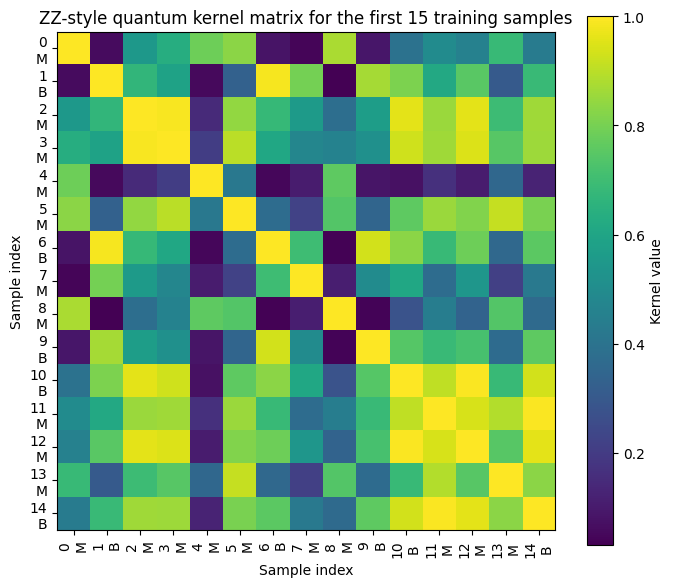

Entangled ZZ-style kernel summary:
  shape = (15, 15)
  average within-class off-diagonal similarity = 0.6271
  average between-class similarity = 0.5145


In [17]:
entangled_kernel_matrix = compute_quantum_kernel_matrix(
    entangled_feature_map_state, X_kernel
)
entangled_within_class_mean, entangled_between_class_mean = summarize_kernel_structure(
    entangled_kernel_matrix, y_kernel
)

print("Entangled ZZ-style kernel matrix:")
display(format_kernel_table(entangled_kernel_matrix, y_kernel))

plot_kernel_matrix(
    entangled_kernel_matrix,
    y_kernel,
    "ZZ-style quantum kernel matrix for the first 15 training samples",
)

print("Entangled ZZ-style kernel summary:")
print("  shape =", entangled_kernel_matrix.shape)
print("  average within-class off-diagonal similarity =", round(float(entangled_within_class_mean), 4))
print("  average between-class similarity =", round(float(entangled_between_class_mean), 4))

### 3.3 Kernel validation

This section checks whether each computed kernel matrix behaves like a valid Gram matrix before using it in downstream models such as an SVM.

The validation cell computes three quantities:

1. Symmetry error

$$
\max_{i,j} \left|K_{ij} - K_{ji}\right|
$$

Meaning:
- It measures how different each pair of mirrored entries is, for example \(K_{ij}\) versus \(K_{ji}\).

Why it matters:
- A valid kernel must be symmetric.
- If this value is near 0, the matrix is numerically symmetric.

How to interpret:
- Very small value (for example around \(10^{-12}\) to \(10^{-15}\)): good.
- Large value: something may be wrong in kernel construction or numerical computation.

2. Diagonal error

$$
\max_i \left|K_{ii} - 1\right|
$$

Meaning:
- It measures how far each self-similarity entry is from 1.

Why it matters:
- Each sample compared with itself should give 1 in ideal simulation.

How to interpret:
- Very small value: good self-consistency.
- Noticeably large value: possible numerical or implementation issue.

3. Minimum eigenvalue

$$
\lambda_{\min}(K)
$$

Meaning:
- It is the smallest eigenvalue of the kernel matrix.

Why it matters:
- A valid kernel matrix should be positive semidefinite (PSD), which means all eigenvalues are nonnegative.

How to interpret:
- Positive or near-zero value: good.
- Tiny negative value (very close to 0): often numerical rounding.
- Clearly negative value: the matrix may not be a valid PSD kernel for SVM.

In [18]:
basic_symmetric_error, basic_diagonal_error, basic_min_eigenvalue = validate_kernel_matrix(
    basic_kernel_matrix
)
entangled_symmetric_error, entangled_diagonal_error, entangled_min_eigenvalue = validate_kernel_matrix(
    entangled_kernel_matrix
)

print("Kernel validation for the first 15 training samples")
print("-" * 55)
print("Basic RX/RZ feature map")
print("  max symmetry error       =", f"{basic_symmetric_error:.3e}")
print("  max diagonal error       =", f"{basic_diagonal_error:.3e}")
print("  minimum eigenvalue       =", f"{basic_min_eigenvalue:.6f}")

print("Entangled ZZ-style feature map")
print("  max symmetry error       =", f"{entangled_symmetric_error:.3e}")
print("  max diagonal error       =", f"{entangled_diagonal_error:.3e}")
print("  minimum eigenvalue       =", f"{entangled_min_eigenvalue:.6f}")

# Validation-focused comparison: lower symmetry/diagonal errors is better, with nonnegative min eigenvalue.
basic_psd_ok = basic_min_eigenvalue >= -1e-10
entangled_psd_ok = entangled_min_eigenvalue >= -1e-10

if basic_psd_ok and entangled_psd_ok:
    if (
        basic_symmetric_error <= entangled_symmetric_error
        and basic_diagonal_error <= entangled_diagonal_error
        and (
            basic_symmetric_error < entangled_symmetric_error
            or basic_diagonal_error < entangled_diagonal_error
        )
    ):
        print("Validation verdict: RX/RZ is slightly better conditioned (smaller numerical errors) while both kernels are valid.")
    elif (
        entangled_symmetric_error <= basic_symmetric_error
        and entangled_diagonal_error <= basic_diagonal_error
        and (
            entangled_symmetric_error < basic_symmetric_error
            or entangled_diagonal_error < basic_diagonal_error
        )
    ):
        print("Validation verdict: ZZ-style is slightly better conditioned (smaller numerical errors) while both kernels are valid.")
    else:
        print("Validation verdict: both kernels are similarly valid; neither is clearly better by the validation checks.")
else:
    if basic_psd_ok and not entangled_psd_ok:
        print("Validation verdict: RX/RZ is better because it satisfies PSD more reliably.")
    elif entangled_psd_ok and not basic_psd_ok:
        print("Validation verdict: ZZ-style is better because it satisfies PSD more reliably.")
    else:
        print("Validation verdict: both kernels need review because PSD is not satisfied robustly.")

Kernel validation for the first 15 training samples
-------------------------------------------------------
Basic RX/RZ feature map
  max symmetry error       = 0.000e+00
  max diagonal error       = 8.882e-16
  minimum eigenvalue       = 0.000000
Entangled ZZ-style feature map
  max symmetry error       = 0.000e+00
  max diagonal error       = 1.332e-15
  minimum eigenvalue       = 0.000000
Validation verdict: RX/RZ is slightly better conditioned (smaller numerical errors) while both kernels are valid.


## Part 4: Classical SVM Training and Evaluation

This part trains classical SVM classifiers using the quantum kernels computed from the two feature maps, then compares them with standard classical SVM kernels.

The benchmark includes:
- SVMs trained on the RX/RZ quantum kernel and the ZZ-style quantum kernel using `kernel="precomputed"`,
- hyperparameter tuning over the SVM regularization parameter $C$,
- accuracy measurement on the held-out test split,
- classical SVM baselines using linear, polynomial, and RBF kernels.

This section uses the full training and test split prepared in Part 2. The training split is used to build the SVM models, and the test split is kept separate for final evaluation.

### 4.1 Use the full train/test split and check class balance

This cell uses the full `X_train`, `y_train`, `X_test`, and `y_test` arrays from Part 2. It also prints the class balance so we can confirm that both the training and test splits contain malignant and benign samples before model training.

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

C_grid = [0.1, 1.0, 10.0, 100.0]

X_svm_train = X_train
y_svm_train = y_train
X_svm_test = X_test
y_svm_test = y_test

# Function to create a class distribution table for a given set of labels and split name
def class_distribution_table(labels, split_name):
    counts = np.bincount(labels, minlength=len(class_names))
    return pd.DataFrame(
        {
            "split": split_name,
            "class_label": class_names,
            "count": counts,
        }
    )

svm_split_distribution = pd.concat(
    [
        class_distribution_table(y_svm_train, "training split"),
        class_distribution_table(y_svm_test, "test split"),
    ],
    ignore_index=True,
)

print("SVM split sizes:")
print("  train samples =", len(X_svm_train))
print("  test samples =", len(X_svm_test))
print("  C grid =", C_grid)
print("Class distribution:")
display(svm_split_distribution)

SVM split sizes:
  train samples = 426
  test samples = 143
  C grid = [0.1, 1.0, 10.0, 100.0]
Class distribution:


,split,class_label,count
0,training split,malignant,159
1,training split,benign,267
2,test split,malignant,53
3,test split,benign,90


### 4.2 Create a validation split for tuning C

This cell creates an internal validation split from the training data only. The validation data is used to choose the best SVM regularization value $C$ before the final model is trained on the full training split.

In [20]:
svm_train_indices = np.arange(len(X_svm_train))
tuning_train_indices, validation_indices = train_test_split(
    svm_train_indices,
    test_size=0.25,
    random_state=123,
    stratify=y_svm_train,
)

print("Tuning split sizes:")
print("  tuning train samples =", len(tuning_train_indices))
print("  validation samples =", len(validation_indices))

Tuning split sizes:
  tuning train samples = 319
  validation samples = 107


### 4.3 Build quantum kernel matrices for SVM training

This cell reuses `compute_quantum_kernel_matrix` from Part 3. With full training data (X_train), it builds the square train-train kernel matrix. With two sample sets (X_train and X_test), it builds the rectangular test-train kernel matrix needed by `SVC(kernel="precomputed")` during prediction.

In [21]:
quantum_kernel_specs = [
    ("Quantum SVM - RX/RZ kernel", "RX/RZ precomputed", basic_feature_map_state),
    ("Quantum SVM - ZZ-style kernel", "ZZ-style precomputed", entangled_feature_map_state),
]

quantum_kernel_matrices = {}

# Compute kernel matrices for both training and test sets for each quantum kernel specification
for model_name, kernel_name, state_fn in quantum_kernel_specs:
    train_kernel = compute_quantum_kernel_matrix(state_fn, X_svm_train)
    test_kernel = compute_quantum_kernel_matrix(state_fn, X_svm_test, X_svm_train)
    quantum_kernel_matrices[model_name] = {
        "kernel": kernel_name,
        "train_kernel": train_kernel,
        "test_kernel": test_kernel,
    }

quantum_kernel_shapes = pd.DataFrame(
    [
        {
            "model": model_name,
            "train_kernel_shape": kernel_data["train_kernel"].shape,
            "test_kernel_shape": kernel_data["test_kernel"].shape,
        }
        for model_name, kernel_data in quantum_kernel_matrices.items()
    ]
)

print("Quantum kernel matrix shapes:")
display(quantum_kernel_shapes)

Quantum kernel matrix shapes:


,model,train_kernel_shape,test_kernel_shape
0,Quantum SVM - RX/RZ kernel,"(426, 426)","(143, 426)"
1,Quantum SVM - ZZ-style kernel,"(426, 426)","(143, 426)"


### 4.4 Define the precomputed-kernel SVM tuning helper

This helper receives a quantum kernel matrix that has already been computed. It tries each candidate value of $C$, evaluates the model on the validation kernel, and returns the best $C$ together with a tuning table.

In [22]:
def tune_precomputed_svm(full_train_kernel, labels, train_indices, val_indices, C_values):
    tuning_rows = []
    train_kernel = full_train_kernel[np.ix_(train_indices, train_indices)]
    validation_kernel = full_train_kernel[np.ix_(val_indices, train_indices)]

    for C in C_values:
        model = SVC(kernel="precomputed", C=C)
        model.fit(train_kernel, labels[train_indices])
        validation_predictions = model.predict(validation_kernel)
        validation_accuracy = accuracy_score(labels[val_indices], validation_predictions)
        tuning_rows.append({"C": C, "validation_accuracy": validation_accuracy})

    tuning_table = pd.DataFrame(tuning_rows)
    best_row = tuning_table.sort_values(
        ["validation_accuracy", "C"], ascending=[False, True]
    ).iloc[0]

    return float(best_row["C"]), float(best_row["validation_accuracy"]), tuning_table

### 4.5 Train SVMs with precomputed quantum kernels

Now each quantum kernel matrix is passed to a classical SVM with `kernel="precomputed"`. The model does not see the original feature vectors at this stage; it only sees the similarity matrix produced by the quantum feature map.

Flow in this cell:

1. Use the tuning/validation split to choose `best_C`.
2. Refit `final_model` on the full training kernel with that `best_C`.
3. Predict on `test_kernel` and compute `test_accuracy`.

In [23]:
quantum_results = []
quantum_tuning_tables = []

# For each quantum kernel, perform C tuning using the tuning/validation split, then evaluate the final model on the test set and record results.
for model_name, kernel_data in quantum_kernel_matrices.items():
    train_kernel = kernel_data["train_kernel"]
    test_kernel = kernel_data["test_kernel"]

    # Tune C using the tuning/validation split
    best_C, validation_accuracy, tuning_table = tune_precomputed_svm(
        train_kernel,
        y_svm_train,
        tuning_train_indices,
        validation_indices,
        C_grid,
    )

    # Train the final model on the full training set using the best C, then evaluate on the test set
    final_model = SVC(kernel="precomputed", C=best_C)
    final_model.fit(train_kernel, y_svm_train)
    test_predictions = final_model.predict(test_kernel)
    test_accuracy = accuracy_score(y_svm_test, test_predictions)

    # Record the results for this quantum kernel model
    quantum_results.append(
        {
            "model_group": "Quantum kernel",
            "model": model_name,
            "kernel": kernel_data["kernel"],
            "best_C": best_C,
            "validation_accuracy": validation_accuracy,
            "test_accuracy": test_accuracy,
            "train_samples": len(X_svm_train),
            "test_samples": len(X_svm_test),
        }
    )

    tuning_table = tuning_table.copy()
    tuning_table.insert(0, "model", model_name)
    quantum_tuning_tables.append(tuning_table)

quantum_tuning_table = pd.concat(quantum_tuning_tables, ignore_index=True)
quantum_results_table = pd.DataFrame(quantum_results)

print("Quantum-kernel SVM C tuning results on the tuning/validation split:")
display(quantum_tuning_table)

print("Final quantum-kernel SVM results on the full train/test split after C selection:")
display(quantum_results_table)

Quantum-kernel SVM C tuning results on the tuning/validation split:


,model,C,validation_accuracy
0,Quantum SVM - RX/RZ kernel,0.1,0.841121
1,Quantum SVM - RX/RZ kernel,1.0,0.859813
2,Quantum SVM - RX/RZ kernel,10.0,0.859813
3,Quantum SVM - RX/RZ kernel,100.0,0.859813
4,Quantum SVM - ZZ-style kernel,0.1,0.831776
5,Quantum SVM - ZZ-style kernel,1.0,0.859813
6,Quantum SVM - ZZ-style kernel,10.0,0.859813
7,Quantum SVM - ZZ-style kernel,100.0,0.841121


Final quantum-kernel SVM results on the full train/test split after C selection:


,model_group,model,kernel,best_C,validation_accuracy,test_accuracy,train_samples,test_samples
0,Quantum kernel,Quantum SVM - RX/RZ kernel,RX/RZ precomputed,1.0,0.859813,0.895105,426,143
1,Quantum kernel,Quantum SVM - ZZ-style kernel,ZZ-style precomputed,1.0,0.859813,0.909091,426,143


### 4.6 Define the classical SVM tuning helper

The classical SVM use the original two scaled features directly. This helper follows the same validation logic as the quantum-kernel SVMs, so the comparison is based on the same $C$ values and the same full train/test split.

In [24]:
def tune_classical_svm(model_name, kernel_name, extra_params=None):
    extra_params = extra_params or {}
    tuning_rows = []

    X_tune_train = X_svm_train[tuning_train_indices]
    y_tune_train = y_svm_train[tuning_train_indices]
    X_validation = X_svm_train[validation_indices]
    y_validation = y_svm_train[validation_indices]

    # Tune C using the tuning/validation split
    for C in C_grid:
        model = SVC(kernel=kernel_name, C=C, **extra_params)
        model.fit(X_tune_train, y_tune_train)
        validation_predictions = model.predict(X_validation)
        validation_accuracy = accuracy_score(y_validation, validation_predictions)
        tuning_rows.append({"model": model_name, "C": C, "validation_accuracy": validation_accuracy})

    tuning_table = pd.DataFrame(tuning_rows)
    best_row = tuning_table.sort_values(
        ["validation_accuracy", "C"], ascending=[False, True]
    ).iloc[0]

    final_model = SVC(kernel=kernel_name, C=float(best_row["C"]), **extra_params)
    final_model.fit(X_svm_train, y_svm_train)
    test_predictions = final_model.predict(X_svm_test)
    test_accuracy = accuracy_score(y_svm_test, test_predictions)

    result = {
        "model_group": "Classical kernel",
        "model": model_name,
        "kernel": kernel_name,
        "best_C": float(best_row["C"]),
        "validation_accuracy": float(best_row["validation_accuracy"]),
        "test_accuracy": test_accuracy,
        "train_samples": len(X_svm_train),
        "test_samples": len(X_svm_test),
    }

    return result, tuning_table

### 4.7 Run the classical SVM baselines

This cell evaluates three standard SVM kernels: linear, polynomial, and RBF. These are the reference models used to judge whether the quantum kernels are competitive on the same full train/test split.

In [25]:
classical_specs = [
    ("Classical SVM - linear kernel", "linear", {}),
    ("Classical SVM - polynomial kernel", "poly", {"degree": 3, "gamma": "scale"}),
    ("Classical SVM - RBF kernel", "rbf", {"gamma": "scale"}),
]

classical_results = []
classical_tuning_tables = []

# For each classical kernel specification, perform C tuning using the tuning/validation split, then evaluate the final model on the test set and record results.
for model_name, kernel_name, extra_params in classical_specs:
    result, tuning_table = tune_classical_svm(model_name, kernel_name, extra_params)
    classical_results.append(result)
    classical_tuning_tables.append(tuning_table)

classical_tuning_table = pd.concat(classical_tuning_tables, ignore_index=True)
classical_results_table = pd.DataFrame(classical_results)

print("Classical SVM C tuning results:")
display(classical_tuning_table)

print("Classical baseline results on the full train/test split:")
display(classical_results_table)

Classical SVM C tuning results:


,model,C,validation_accuracy
0,Classical SVM - linear kernel,0.1,0.850467
1,Classical SVM - linear kernel,1.0,0.859813
2,Classical SVM - linear kernel,10.0,0.859813
3,Classical SVM - linear kernel,100.0,0.859813
4,Classical SVM - polynomial kernel,0.1,0.859813
5,Classical SVM - polynomial kernel,1.0,0.850467
6,Classical SVM - polynomial kernel,10.0,0.850467
7,Classical SVM - polynomial kernel,100.0,0.850467
8,Classical SVM - RBF kernel,0.1,0.859813
9,Classical SVM - RBF kernel,1.0,0.869159


Classical baseline results on the full train/test split:


,model_group,model,kernel,best_C,validation_accuracy,test_accuracy,train_samples,test_samples
0,Classical kernel,Classical SVM - linear kernel,linear,1.0,0.859813,0.874126,426,143
1,Classical kernel,Classical SVM - polynomial kernel,poly,0.1,0.859813,0.895105,426,143
2,Classical kernel,Classical SVM - RBF kernel,rbf,1.0,0.869159,0.888112,426,143


### 4.8 Compare quantum and classical SVM performance

The final comparison combines the quantum-kernel SVM results and the classical baseline results into one table and one accuracy plot.

Combined performance comparison:


,model_group,model,kernel,best_C,validation_accuracy,test_accuracy,train_samples,test_samples
1,Quantum kernel,Quantum SVM - ZZ-style kernel,ZZ-style precomputed,1.0,0.859813,0.909091,426,143
0,Quantum kernel,Quantum SVM - RX/RZ kernel,RX/RZ precomputed,1.0,0.859813,0.895105,426,143
3,Classical kernel,Classical SVM - polynomial kernel,poly,0.1,0.859813,0.895105,426,143
4,Classical kernel,Classical SVM - RBF kernel,rbf,1.0,0.869159,0.888112,426,143
2,Classical kernel,Classical SVM - linear kernel,linear,1.0,0.859813,0.874126,426,143


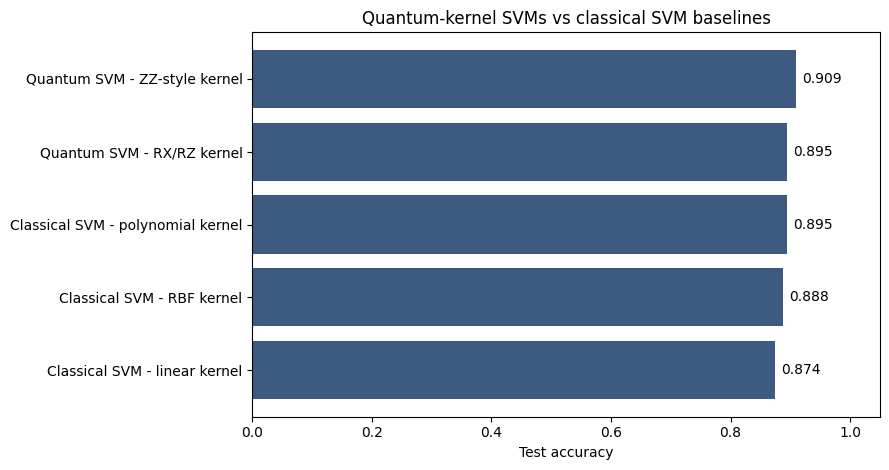

In [26]:
performance_results = pd.concat(
    [quantum_results_table, classical_results_table], ignore_index=True
).sort_values("test_accuracy", ascending=False)

print("Combined performance comparison:")
display(performance_results)

plt.figure(figsize=(9, 4.8))
plot_results = performance_results.sort_values("test_accuracy", ascending=True)
plt.barh(plot_results["model"], plot_results["test_accuracy"], color="#3D5A80")
plt.xlim(0.0, 1.05)
plt.xlabel("Test accuracy")
plt.title("Quantum-kernel SVMs vs classical SVM baselines")

for index, accuracy in enumerate(plot_results["test_accuracy"]):
    plt.text(
        accuracy + 0.01,
        index,
        f"{accuracy:.3f}",
        va="center",
    )

plt.tight_layout()
plt.show()

## Part 5: Angle Embedding with PCA

This part adds a new QSVM experiment using `AngleEmbedding`.

The main difference from Part 4 is the input representation:
- Part 4 used two original features, `mean radius` and `mean texture`, then tested two custom quantum feature maps.
- Part 5 first applies PCA to the full Breast Cancer Wisconsin feature set, keeps two principal components, scales them into angles, and uses PennyLane's built-in `AngleEmbedding` template.


### 5.1 Prepare PCA features

PCA stands for Principal Component Analysis. It creates new features called principal components. These new features are weighted combinations of the original dataset features.

Here we use PCA for one practical reason: the original Breast Cancer Wisconsin dataset has 30 numeric features, but our quantum circuit uses only 2 qubits. To keep the circuit small, PCA compresses the 30 original features into 2 features (PCA components).

PCA explained variance tells us how much of the original data variation is captured by each principal component. The explained variance ratio for one component is

$$
\text{explained variance ratio} = \frac{\text{variance captured by that component}}{\text{total variance in the original standardized features}}.
$$

For example, if PC1 has explained variance ratio 0.44, then PC1 captures about 44% of the total variation in the original feature set. If PC2 has explained variance ratio 0.20, then the first two PCA features together capture about 64% of the variation.

This is important because PCA reduces dimensionality by discarding some information. Explained variance helps us check how much information is kept after reducing 30 features to 2 features. A higher combined explained variance means the two PCA components preserve more of the original dataset structure, which can give the QSVM a more informative input representation. However, explained variance does not directly measure class separation. A component can capture a lot of variation without being the best direction for classification, so we still need the final QSVM accuracy to evaluate model performance.

The preprocessing order is important:

1. Split the data into training and test sets.
2. Fit the standard scaler on the training data only.
3. Fit PCA on the standardized training data only.
4. Transform the test data using the training scaler and training PCA model.
5. Scale the two PCA components to $[0, \pi]$ so they can be used as quantum rotation angles.

Fitting preprocessing steps only on the training data avoids leaking information from the test set into the model.

In [56]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_pca_raw = data.data.copy()
y_pca = y.copy()

# Split the dataset into training and test sets for PCA processing
X_pca_raw_train, X_pca_raw_test, y_angle_train, y_angle_test = train_test_split(
    X_pca_raw,
    y_pca,
    test_size=0.25,
    random_state=42,
    stratify=y_pca,
)

# Standardize the features before applying PCA
pca_standard_scaler = StandardScaler()
X_pca_train_standardized = pca_standard_scaler.fit_transform(X_pca_raw_train)
X_pca_test_standardized = pca_standard_scaler.transform(X_pca_raw_test)

# Apply PCA to reduce to 2 components for angle encoding
pca_model = PCA(n_components=2, random_state=42)
X_pca_train = pca_model.fit_transform(X_pca_train_standardized)
X_pca_test = pca_model.transform(X_pca_test_standardized)

# Scale the PCA components to the range [0, pi] for angle encoding
angle_scaler = MinMaxScaler(feature_range=(0.0, np.pi))
X_angle_train = angle_scaler.fit_transform(X_pca_train)
X_angle_test = angle_scaler.transform(X_pca_test)
X_angle_test = np.clip(X_angle_test, 0.0, np.pi)

pca_explained_variance = pd.DataFrame(
    {
        "principal_component": ["PC1", "PC2"],
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
    }
)

angle_split_distribution = pd.concat(
    [
        class_distribution_table(y_angle_train, "training split"),
        class_distribution_table(y_angle_test, "test split"),
    ],
    ignore_index=True,
)

print("Original feature count:", X_pca_raw.shape[1])
print("PCA feature count:", X_angle_train.shape[1])
print("Training samples:", len(X_angle_train))
print("Test samples:", len(X_angle_test))
print("Training angle range:", round(float(X_angle_train.min()), 4), "to", round(float(X_angle_train.max()), 4))
print("Test angle range:", round(float(X_angle_test.min()), 4), "to", round(float(X_angle_test.max()), 4))
print("PCA explained variance:")
display(pca_explained_variance)
print("Class distribution:")
display(angle_split_distribution)

Original feature count: 30
PCA feature count: 2
Training samples: 426
Test samples: 143
Training angle range: 0.0 to 3.1416
Test angle range: 0.0 to 3.1416
PCA explained variance:


,principal_component,explained_variance_ratio
0,PC1,0.438954
1,PC2,0.195189


Class distribution:


,split,class_label,count
0,training split,malignant,159
1,training split,benign,267
2,test split,malignant,53
3,test split,benign,90


### 5.2 Visualize the PCA representation

The two PCA coordinates are not original medical measurements. They are new axes that summarize variation across all 30 original features.

This plot helps us inspect whether the two PCA components already show some class separation before we encode them into a quantum circuit.

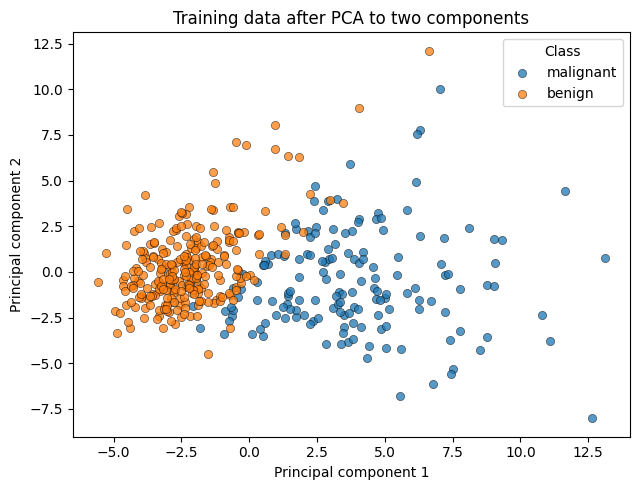

In [93]:
plt.figure(figsize=(6.5, 5))
for class_index, class_name in enumerate(class_names):
    class_mask = y_angle_train == class_index
    plt.scatter(
        X_pca_train[class_mask, 0],
        X_pca_train[class_mask, 1],
        label=class_name,
        edgecolor="black",
        alpha=0.75,
        s=35,
        linewidth=0.4,
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Training data after PCA to two components")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### 5.3 Implement AngleEmbedding

`AngleEmbedding` is a PennyLane template that encodes classical numbers as quantum rotation angles.

For a two-feature input $x = [x_1, x_2]$, this experiment uses two qubits and applies one rotation per qubit:

$$
|\phi(x)\rangle = R_Y(x_1) \otimes R_Y(x_2)|00\rangle.
$$

In simple terms, each PCA value becomes the angle of a quantum gate. After that, the QSVM uses state overlaps between these angle-encoded states as kernel values.

In [94]:
def angle_embedding_feature_map(x):
    qml.AngleEmbedding(x, wires=wires, rotation="Y")

@qml.qnode(dev)
def angle_embedding_circuit(x):
    angle_embedding_feature_map(x)
    return qml.probs(wires=wires)

@qml.qnode(dev)
def angle_embedding_state(x):
    angle_embedding_feature_map(x)
    return qml.state()

### 5.4 Visualize the AngleEmbedding circuit

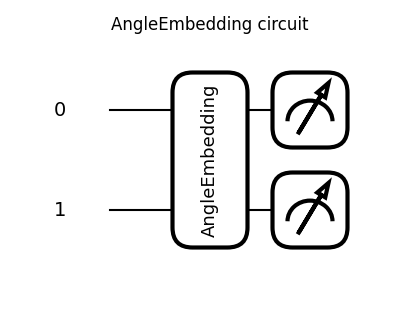

In [101]:
fig_angle, _ = qml.draw_mpl(angle_embedding_circuit, decimals=2)([])
fig_angle.suptitle(f"AngleEmbedding circuit")
plt.show()

### 5.5 Build the AngleEmbedding quantum kernel

The QSVM does not train directly on the PCA coordinates. Instead, the PCA coordinates are first encoded into quantum states with `AngleEmbedding`.

The kernel is computed in the same way as Part 3:

$$
K(x_i, x_j) = |\langle \phi(x_i) | \phi(x_j) \rangle|^2.
$$

For training, we need a train-train kernel matrix. For prediction, we need a test-train kernel matrix.

In [102]:
angle_train_kernel = compute_quantum_kernel_matrix(angle_embedding_state, X_angle_train)
angle_test_kernel = compute_quantum_kernel_matrix(angle_embedding_state, X_angle_test, X_angle_train)

angle_symmetric_error, angle_diagonal_error, angle_min_eigenvalue = validate_kernel_matrix(
    angle_train_kernel
)

angle_kernel_report = pd.DataFrame(
    [
        {
            "kernel": "PCA AngleEmbedding",
            "train_kernel_shape": angle_train_kernel.shape,
            "test_kernel_shape": angle_test_kernel.shape,
            "max_symmetry_error": angle_symmetric_error,
            "max_diagonal_error": angle_diagonal_error,
            "minimum_eigenvalue": angle_min_eigenvalue,
        }
    ]
)

print("AngleEmbedding quantum kernel report:")
display(angle_kernel_report)

AngleEmbedding quantum kernel report:


,kernel,train_kernel_shape,test_kernel_shape,max_symmetry_error,max_diagonal_error,minimum_eigenvalue
0,PCA AngleEmbedding,"(426, 426)","(143, 426)",0.0,8.881784e-16,-1.650963e-13


### 5.6 Train the AngleEmbedding QSVM

This cell trains a QSVM using the AngleEmbedding kernel.

The training process follows the same logic as Part 4:

1. Split the training rows into a smaller tuning set and a validation set.
2. Try each value of $C$ from `C_grid`.
3. Pick the $C$ value with the best validation accuracy.
4. Retrain the final QSVM on the full training kernel.
5. Evaluate it on the held-out test kernel.

In [103]:
angle_train_indices = np.arange(len(X_angle_train))
angle_tuning_train_indices, angle_validation_indices = train_test_split(
    angle_train_indices,
    test_size=0.25,
    random_state=123,
    stratify=y_angle_train,
)

angle_best_C, angle_validation_accuracy, angle_tuning_table = tune_precomputed_svm(
    angle_train_kernel,
    y_angle_train,
    angle_tuning_train_indices,
    angle_validation_indices,
    C_grid,
)

angle_qsvm_model = SVC(kernel="precomputed", C=angle_best_C)
angle_qsvm_model.fit(angle_train_kernel, y_angle_train)
angle_qsvm_predictions = angle_qsvm_model.predict(angle_test_kernel)
angle_qsvm_test_accuracy = accuracy_score(y_angle_test, angle_qsvm_predictions)

angle_qsvm_results_table = pd.DataFrame(
    [
        {
            "model_group": "Quantum kernel",
            "model": "QSVM - PCA AngleEmbedding",
            "kernel": "PCA AngleEmbedding precomputed",
            "best_C": angle_best_C,
            "validation_accuracy": angle_validation_accuracy,
            "test_accuracy": angle_qsvm_test_accuracy,
            "train_samples": len(X_angle_train),
            "test_samples": len(X_angle_test),
        }
    ]
)

print("AngleEmbedding QSVM C tuning results:")
display(angle_tuning_table)

print("AngleEmbedding QSVM result:")
display(angle_qsvm_results_table)

AngleEmbedding QSVM C tuning results:


,C,validation_accuracy
0,0.1,0.887850
1,1.0,0.915888
2,10.0,0.925234
3,100.0,0.925234


AngleEmbedding QSVM result:


,model_group,model,kernel,best_C,validation_accuracy,test_accuracy,train_samples,test_samples
0,Quantum kernel,QSVM - PCA AngleEmbedding,PCA AngleEmbedding precomputed,10.0,0.925234,0.944056,426,143


### 5.7 Compare AngleEmbedding with Part 4

The comparison is not only about the quantum circuit. Two things changed at the same time:

- Part 4 used two original features selected by name.
- Part 5 uses two PCA components computed from all 30 original features.

Part 5 vs Part 4 accuracy comparison:


,model_group,model,kernel,best_C,validation_accuracy,test_accuracy,angle_minus_this_model
5,Quantum kernel,QSVM - PCA AngleEmbedding,PCA AngleEmbedding precomputed,10.0,0.925234,0.944056,0.000000
0,Quantum kernel,Quantum SVM - ZZ-style kernel,ZZ-style precomputed,1.0,0.859813,0.909091,0.034965
1,Quantum kernel,Quantum SVM - RX/RZ kernel,RX/RZ precomputed,1.0,0.859813,0.895105,0.048951
2,Classical kernel,Classical SVM - polynomial kernel,poly,0.1,0.859813,0.895105,0.048951
3,Classical kernel,Classical SVM - RBF kernel,rbf,1.0,0.869159,0.888112,0.055944
4,Classical kernel,Classical SVM - linear kernel,linear,1.0,0.859813,0.874126,0.069930


AngleEmbedding QSVM test accuracy: 0.944
Best Part 4 model: Quantum SVM - ZZ-style kernel with test accuracy 0.909
AngleEmbedding is higher than the best Part 4 result by 0.035


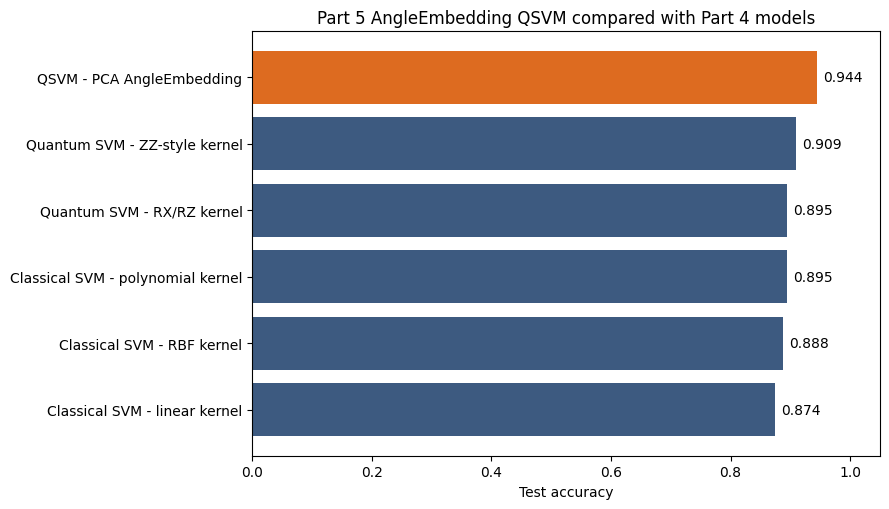

In [106]:
part4_accuracy_table = performance_results[
    ["model_group", "model", "kernel", "best_C", "validation_accuracy", "test_accuracy"]
].copy()

part5_accuracy_comparison = pd.concat(
    [part4_accuracy_table, angle_qsvm_results_table[part4_accuracy_table.columns]],
    ignore_index=True,
)
part5_accuracy_comparison["angle_minus_this_model"] = (
    angle_qsvm_test_accuracy - part5_accuracy_comparison["test_accuracy"]
)
part5_accuracy_comparison = part5_accuracy_comparison.sort_values(
    "test_accuracy", ascending=False
)

best_part4_row = part4_accuracy_table.sort_values("test_accuracy", ascending=False).iloc[0]
best_part4_accuracy = float(best_part4_row["test_accuracy"])
accuracy_gap_vs_best_part4 = angle_qsvm_test_accuracy - best_part4_accuracy

print("Part 5 vs Part 4 accuracy comparison:")
display(part5_accuracy_comparison)

print("AngleEmbedding QSVM test accuracy:", f"{angle_qsvm_test_accuracy:.3f}")
print(
    "Best Part 4 model:",
    best_part4_row["model"],
    "with test accuracy",
    f"{best_part4_accuracy:.3f}",
)

if accuracy_gap_vs_best_part4 > 0:
    print("AngleEmbedding is higher than the best Part 4 result by", f"{accuracy_gap_vs_best_part4:.3f}")
elif accuracy_gap_vs_best_part4 < 0:
    print("AngleEmbedding is lower than the best Part 4 result by", f"{abs(accuracy_gap_vs_best_part4):.3f}")
else:
    print("AngleEmbedding matches the best Part 4 result.")

plt.figure(figsize=(9, 5.2))
plot_comparison = part5_accuracy_comparison.sort_values("test_accuracy", ascending=True)
bar_colors = [
    "#DD6B20" if model == "QSVM - PCA AngleEmbedding" else "#3D5A80"
    for model in plot_comparison["model"]
]
plt.barh(plot_comparison["model"], plot_comparison["test_accuracy"], color=bar_colors)
plt.xlim(0.0, 1.05)
plt.xlabel("Test accuracy")
plt.title("Part 5 AngleEmbedding QSVM compared with Part 4 models")

for index, accuracy in enumerate(plot_comparison["test_accuracy"]):
    plt.text(accuracy + 0.01, index, f"{accuracy:.3f}", va="center")

plt.tight_layout()
plt.show()